# 03 · Data Cleaning
**Project:** LendingClub loan default prediction  
**Input:** `data/interim/accepted_2007_to_201804.parquet`  
**Output:** cleaned dataset in `data/interim/` (parquet), *to be written at the end of this notebook*

---

## Contents
1. Setup and data loading
2. Remove invalid rows
3. Define the target
4. Scope and column selection
5. Missingness assessment
6. Summary and remaining work

---

## Cleaning plan and status

| # | Step | Status |
|---|------|--------|
| 1 | Remove invalid rows and check for duplicates | Done |
| 2 | Define the binary target and remove loans without a known outcome | Done |
| 3 | Apply the column selection (candidate features, target, `issue_d`) | Done |
| 4 | Fix data types (`term`, `emp_length`, `zip_code`; credit-line dates are already datetime) | Pending |
| 5 | Assess missingness in numeric candidates | In progress |
| 6 | Handle joint applications | Done: scope restricted to individual applications |
| 7 | Check value validity (`dti`, `annual_inc`, `revol_util`, FICO low > high) | Pending |
| 8 | Clean categorical fields (rare categories, `addr_state`, `zip_code`) | Pending |
| 9 | Save the cleaned dataset and log row/column counts | Pending |

## Scope of this notebook
Only **stateless** cleaning is done here: rules that learn nothing from the data (invalid rows, target definition, column selection, type conversion, text standardisation).

Anything that is **fitted on the data** (imputers, encoders, scalers, percentile-based capping thresholds) must happen *after* the time-based split on `issue_d`, using the training data only, to avoid leakage.

## 1. Setup and data loading

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

DATA_PATH = Path("..") / "data" / "interim" / "accepted_2007_to_201804.parquet"
TARGET = "default"
SPLIT_KEY = "issue_d"

# Row/column counts after each cleaning step
step_log = []


def log_step(step: str, frame: pd.DataFrame) -> None:
    step_log.append({"step": step, "rows": len(frame), "columns": frame.shape[1]})

In [2]:
df = pd.read_parquet(DATA_PATH)
log_step("Raw data loaded", df)

print(f"Raw data: {df.shape[0]:,} rows x {df.shape[1]} columns")

Raw data: 2,260,701 rows x 151 columns


## 2. Remove invalid rows

### 2.1 Rows with missing core categorical values
Fields such as `term`, `grade`, `purpose` and `loan_status` should be populated for every real loan. Rows where any of them is missing are inspected first.

In [3]:
low_null_cols = [
    "term",
    "grade",
    "sub_grade",
    "home_ownership",
    "verification_status",
    "loan_status",
    "pymnt_plan",
    "purpose",
    "initial_list_status",
    "application_type",
    "hardship_flag",
    "disbursement_method",
    "debt_settlement_flag",
    "addr_state",
    "zip_code",
]

invalid_mask = df[low_null_cols].isna().any(axis=1)
invalid_rows = df.loc[invalid_mask]

non_numeric_ids = pd.to_numeric(invalid_rows["id"], errors="coerce").isna().sum()

print(f"Rows with a missing core categorical value: {invalid_mask.sum():,} ({invalid_mask.mean():.4%} of all rows)")
print(f"Share of null cells in those rows:          {invalid_rows.isna().mean().mean():.2%}")
print(f"Rows with a non-numeric loan id:            {non_numeric_ids} of {len(invalid_rows)}")

invalid_rows[["id", "loan_status"]].head(6)

Rows with a missing core categorical value: 34 (0.0015% of all rows)
Share of null cells in those rows:          97.27%
Rows with a non-numeric loan id:            33 of 34


,id,loan_status
421095,Total amount funded in policy code 1: 6417608175,None
421096,Total amount funded in policy code 2: 1944088810,None
528961,Total amount funded in policy code 1: 1741781700,None
528962,Total amount funded in policy code 2: 564202131,None
651664,Total amount funded in policy code 1: 1791201400,None
651665,Total amount funded in policy code 2: 651669342,None


These rows are not loans. They are summary lines from the original export (their `id` reads "Total amount funded in policy code ...") and are about 97% null, so they are removed.

In [4]:
df = df.drop(index=invalid_rows.index)
log_step("Invalid summary rows removed", df)

print(f"Shape after removal: {df.shape}")

Shape after removal: (2260667, 151)


### 2.2 Duplicate check
Every loan has a unique `id`, so unique ids also rule out fully duplicated rows. This is much cheaper than comparing all 151 columns of 2.2 million rows.

In [5]:
n_duplicate_ids = df["id"].duplicated().sum()
print(f"Duplicated loan ids: {n_duplicate_ids:,}")

df = df.drop_duplicates(subset="id")  # no-op when there are no duplicates
log_step("Duplicates checked", df)

Duplicated loan ids: 0


## 3. Define the target

### 3.1 Loan status mapping
Only loans with a **final, known outcome** are used for modelling. Loans that are still in their repayment lifecycle have no outcome yet, so they are excluded rather than guessed.

| `loan_status` | Meaning | Treatment | Reason |
|---|---|---|---|
| Fully Paid | Borrower repaid the loan in full | `default = 0` | Known good outcome |
| Does not meet the credit policy. Status:Fully Paid | Older loan outside the current credit policy, fully repaid | `default = 0` | Known good outcome |
| Charged Off | Lender considers the loan unlikely to be recovered | `default = 1` | Known bad outcome |
| Does not meet the credit policy. Status:Charged Off | Older loan outside the current credit policy, charged off | `default = 1` | Known bad outcome |
| Default | Loan has formally defaulted | `default = 1` | Known bad outcome |
| Current | Being paid on schedule | Excluded | Outcome not known yet |
| In Grace Period | Overdue, but within the grace period | Excluded | Still in the repayment lifecycle |
| Late (16-30 days) | 16-30 days overdue | Excluded | Not necessarily a default |
| Late (31-120 days) | 31-120 days overdue | Excluded | Serious delinquency, but not a final outcome |

In [6]:
STATUS_TO_TARGET = {
    "Fully Paid": 0,
    "Does not meet the credit policy. Status:Fully Paid": 0,
    "Charged Off": 1,
    "Does not meet the credit policy. Status:Charged Off": 1,
    "Default": 1,
}

EXCLUDED_STATUSES = [
    "Current",
    "In Grace Period",
    "Late (16-30 days)",
    "Late (31-120 days)",
]

# Every status in the data must be handled explicitly
unhandled = set(df["loan_status"].unique()) - set(STATUS_TO_TARGET) - set(EXCLUDED_STATUSES)
assert not unhandled, f"Unmapped loan_status values: {unhandled}"

status_summary = df["loan_status"].value_counts().rename("loans").to_frame()
status_summary["share_%"] = status_summary["loans"] / len(df) * 100
status_summary["treatment"] = [
    f"default = {STATUS_TO_TARGET[s]}" if s in STATUS_TO_TARGET else "excluded"
    for s in status_summary.index
]
status_summary

,loans,share_%,treatment
loan_status,,,
Fully Paid,1076750,47.63,default = 0
Current,878317,38.85,excluded
Charged Off,268559,11.88,default = 1
Late (31-120 days),21467,0.95,excluded
In Grace Period,8436,0.37,excluded
Late (16-30 days),4349,0.19,excluded
Does not meet the credit policy. Status:Fully Paid,1988,0.09,default = 0
Does not meet the credit policy. Status:Charged Off,761,0.03,default = 1
Default,40,0.00,default = 1


### 3.2 Build the modelling dataset

In [7]:
resolved = df["loan_status"].isin(STATUS_TO_TARGET)

df_model = df.loc[resolved].copy()
df_model[TARGET] = df_model["loan_status"].map(STATUS_TO_TARGET).astype("int8")

n_excluded = int((~resolved).sum())
assert n_excluded == df["loan_status"].isin(EXCLUDED_STATUSES).sum()

log_step("Loans without a known outcome removed; target created", df_model)

print(f"Loans with a known outcome: {len(df_model):,}")
print(f"Loans excluded (no final outcome yet): {n_excluded:,}")

class_balance = df_model[TARGET].value_counts().sort_index().rename("loans").to_frame()
class_balance["share_%"] = class_balance["loans"] / len(df_model) * 100
class_balance.index = ["0  (repaid)", "1  (default)"]
class_balance

Loans with a known outcome: 1,348,098
Loans excluded (no final outcome yet): 912,569


,loans,share_%
0 (repaid),1078738,80.02
1 (default),269360,19.98


### 3.3 Outcome coverage by issue year
Recent loans are more likely to be unresolved, so the retained sample is not equally complete for every year. This matters for the time-based split.

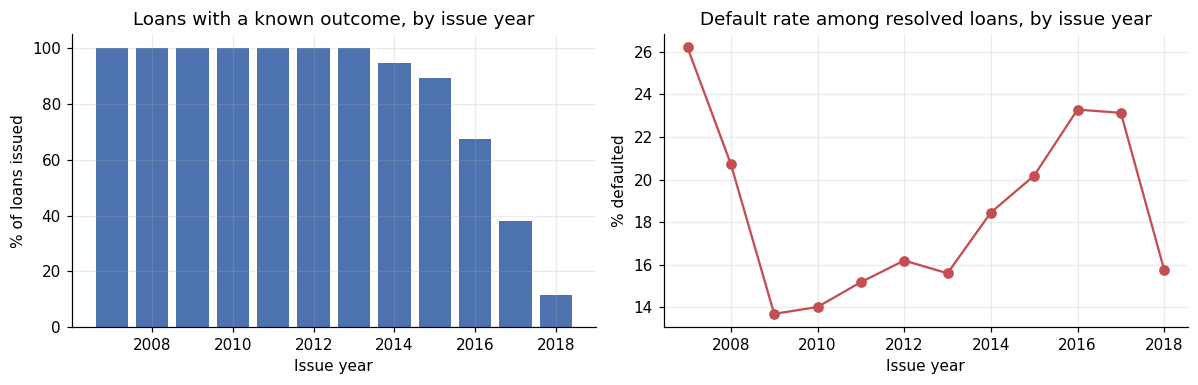

,loans,resolved_share,default_rate_%
year,,,
2007,603,100.00,26.20
2008,2393,100.00,20.73
2009,5281,100.00,13.69
2010,12537,100.00,14.01
2011,21721,100.00,15.18
2012,53367,100.00,16.20
2013,134814,99.99,15.60
2014,235629,94.68,18.45
2015,421095,89.18,20.19


In [8]:
issue_year = pd.to_datetime(df[SPLIT_KEY]).dt.year

vintage = pd.DataFrame({"year": issue_year, "resolved": resolved}).groupby("year")["resolved"].agg(
    loans="size", resolved_share=lambda s: s.mean() * 100
)
vintage["default_rate_%"] = (
    df_model.groupby(pd.to_datetime(df_model[SPLIT_KEY]).dt.year)[TARGET].mean() * 100
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].bar(vintage.index, vintage["resolved_share"], color="#4C72B0")
axes[0].set_title("Loans with a known outcome, by issue year")
axes[0].set_ylabel("% of loans issued")

axes[1].plot(vintage.index, vintage["default_rate_%"], marker="o", color="#C44E52")
axes[1].set_title("Default rate among resolved loans, by issue year")
axes[1].set_ylabel("% defaulted")

for ax in axes:
    ax.set_xlabel("Issue year")

plt.tight_layout()
plt.show()

vintage

**Note.** Loans issued in the most recent years are mostly unresolved. Those that are resolved tend to be early charge-offs or early repayments, so their default rate is not comparable with older years. The sample window (for example, cutting off the latest issue years) should be decided before the split, using this table.

In [9]:
del df  # free memory: only the modelling dataset is needed from here on

## 4. Scope and column selection

### 4.1 Restrict to individual applications
The project models **individual applicants only**. Joint applications carry a second applicant's income, DTI and credit history, which would need a separate treatment, so they are out of scope.

In [10]:
print(df_model["application_type"].value_counts().to_string())

df_model = df_model.loc[df_model["application_type"] == "Individual"]
log_step("Restricted to individual applications", df_model)

print(f"\nRows after restriction: {len(df_model):,}")

application_type
Individual    1322292
Joint App       25806

Rows after restriction: 1,322,292


### 4.2 Column classification
Each column is assigned to a group, and each group has a keep/drop decision. `issue_d` is kept in its own group because it is needed for the time-based split, but it must **not** be used as a feature.

In [11]:
column_categories = {
    "Application Information": [
        "loan_amnt",
        "term",
        "emp_length",
        "home_ownership",
        "annual_inc",
        "verification_status",
        "purpose",
        "zip_code",
        "addr_state",
        "dti",
    ],

    "Credit History": [
        "delinq_2yrs",
        "earliest_cr_line",
        "fico_range_low",
        "fico_range_high",
        "inq_last_6mths",
        "mths_since_last_delinq",
        "mths_since_last_record",
        "open_acc",
        "pub_rec",
        "revol_bal",
        "revol_util",
        "total_acc",
        "collections_12_mths_ex_med",
        "mths_since_last_major_derog",
        "acc_now_delinq",
        "tot_coll_amt",
        "tot_cur_bal",
        "open_acc_6m",
        "open_act_il",
        "open_il_12m",
        "open_il_24m",
        "mths_since_rcnt_il",
        "total_bal_il",
        "il_util",
        "open_rv_12m",
        "open_rv_24m",
        "max_bal_bc",
        "all_util",
        "total_rev_hi_lim",
        "inq_fi",
        "total_cu_tl",
        "inq_last_12m",
        "acc_open_past_24mths",
        "avg_cur_bal",
        "bc_open_to_buy",
        "bc_util",
        "chargeoff_within_12_mths",
        "delinq_amnt",
        "mo_sin_old_il_acct",
        "mo_sin_old_rev_tl_op",
        "mo_sin_rcnt_rev_tl_op",
        "mo_sin_rcnt_tl",
        "mort_acc",
        "mths_since_recent_bc",
        "mths_since_recent_bc_dlq",
        "mths_since_recent_inq",
        "mths_since_recent_revol_delinq",
        "num_accts_ever_120_pd",
        "num_actv_bc_tl",
        "num_actv_rev_tl",
        "num_bc_sats",
        "num_bc_tl",
        "num_il_tl",
        "num_op_rev_tl",
        "num_rev_accts",
        "num_rev_tl_bal_gt_0",
        "num_sats",
        "num_tl_120dpd_2m",
        "num_tl_30dpd",
        "num_tl_90g_dpd_24m",
        "num_tl_op_past_12m",
        "pct_tl_nvr_dlq",
        "percent_bc_gt_75",
        "pub_rec_bankruptcies",
        "tax_liens",
        "tot_hi_cred_lim",
        "total_bal_ex_mort",
        "total_bc_limit",
        "total_il_high_credit_limit",
    ],

    "Joint Application / Credit History": [
        "application_type",
        "annual_inc_joint",
        "dti_joint",
        "verification_status_joint",
        "revol_bal_joint",
        "sec_app_fico_range_low",
        "sec_app_fico_range_high",
        "sec_app_earliest_cr_line",
        "sec_app_inq_last_6mths",
        "sec_app_mort_acc",
        "sec_app_open_acc",
        "sec_app_revol_util",
        "sec_app_open_act_il",
        "sec_app_num_rev_accts",
        "sec_app_chargeoff_within_12_mths",
        "sec_app_collections_12_mths_ex_med",
        "sec_app_mths_since_last_major_derog",
    ],

    "Lender-Assigned / Listing Attributes": [
        "int_rate",
        "installment",
        "grade",
        "sub_grade",
        "initial_list_status",
    ],

    "Funding / Loan Issuance": [
        "funded_amnt",
        "funded_amnt_inv",
        "disbursement_method",
    ],

    "Post-Loan Performance": [
        "out_prncp",
        "out_prncp_inv",
        "total_pymnt",
        "total_pymnt_inv",
        "total_rec_prncp",
        "total_rec_int",
        "total_rec_late_fee",
        "recoveries",
        "collection_recovery_fee",
        "last_pymnt_d",
        "last_pymnt_amnt",
        "next_pymnt_d",
        "last_credit_pull_d",
        "last_fico_range_high",
        "last_fico_range_low",
        "pymnt_plan",
    ],

    "Hardship / Payment Modification": [
        "hardship_flag",
        "hardship_type",
        "hardship_reason",
        "hardship_status",
        "deferral_term",
        "hardship_amount",
        "hardship_start_date",
        "hardship_end_date",
        "payment_plan_start_date",
        "hardship_length",
        "hardship_dpd",
        "hardship_loan_status",
        "orig_projected_additional_accrued_interest",
        "hardship_payoff_balance_amount",
        "hardship_last_payment_amount",
    ],

    "Debt Settlement": [
        "debt_settlement_flag",
        "debt_settlement_flag_date",
        "settlement_status",
        "settlement_date",
        "settlement_amount",
        "settlement_percentage",
        "settlement_term",
    ],

    "Identifiers / Administrative": [
        "id",
        "member_id",
        "url",
        "policy_code",
    ],

    "Text / Free Text": [
        "emp_title",
        "title",
        "desc",
    ],

    "Split Key": [
        SPLIT_KEY,
    ],

    "Target Source": [
        "loan_status",
    ],
}

category_decisions = {
    "Application Information": ("Keep", "Candidate feature"),
    "Credit History": ("Keep", "Candidate feature"),
    "Joint Application / Credit History": ("Drop", "Out of scope: individual applications only"),
    "Lender-Assigned / Listing Attributes": ("Drop", "Excluded from the feature set by design"),
    "Funding / Loan Issuance": ("Drop", "Excluded from the feature set by design"),
    "Post-Loan Performance": ("Drop", "Only known after origination (leakage)"),
    "Hardship / Payment Modification": ("Drop", "Only known after origination (leakage)"),
    "Debt Settlement": ("Drop", "Only known after origination (leakage)"),
    "Identifiers / Administrative": ("Drop", "No predictive meaning"),
    "Text / Free Text": ("Drop", "Free text, out of scope"),
    "Split Key": ("Keep", "Used for the time-based split only, not a feature"),
    "Target Source": ("Drop", f"Replaced by the binary `{TARGET}` target"),
}

classification_df = pd.DataFrame(
    [
        {
            "Column": col,
            "Category": category,
            "Decision": category_decisions[category][0],
            "Reason": category_decisions[category][1],
        }
        for category, columns in column_categories.items()
        for col in columns
    ]
)

# Every column must be classified exactly once
assert classification_df["Column"].is_unique, "A column appears in more than one category"
unclassified = set(df_model.columns) - set(classification_df["Column"]) - {TARGET}
absent = set(classification_df["Column"]) - set(df_model.columns)
assert not unclassified, f"Unclassified columns: {sorted(unclassified)}"
assert not absent, f"Classified columns not in the data: {sorted(absent)}"

(
    classification_df
    .groupby(["Category", "Decision", "Reason"], sort=False)
    .size()
    .rename("columns")
    .reset_index()
)

,Category,Decision,Reason,columns
0,Application Information,Keep,Candidate feature,10
1,Credit History,Keep,Candidate feature,69
2,Joint Application / Credit History,Drop,Out of scope: individual applications only,17
3,Lender-Assigned / Listing Attributes,Drop,Excluded from the feature set by design,5
4,Funding / Loan Issuance,Drop,Excluded from the feature set by design,3
5,Post-Loan Performance,Drop,Only known after origination (leakage),16
6,Hardship / Payment Modification,Drop,Only known after origination (leakage),15
7,Debt Settlement,Drop,Only known after origination (leakage),7
8,Identifiers / Administrative,Drop,No predictive meaning,4
9,Text / Free Text,Drop,"Free text, out of scope",3


### 4.3 Apply the column selection

In [12]:
drop_cols = classification_df.loc[classification_df["Decision"] == "Drop", "Column"].tolist()
df_model = df_model.drop(columns=drop_cols)
log_step("Column selection applied", df_model)

feature_cols = [c for c in df_model.columns if c not in (TARGET, SPLIT_KEY)]

print(f"Dropped {len(drop_cols)} columns")
print(f"Remaining: {len(feature_cols)} candidate features + target (`{TARGET}`) + split key (`{SPLIT_KEY}`)")

Dropped 71 columns
Remaining: 79 candidate features + target (`default`) + split key (`issue_d`)


## 5. Missingness assessment
Missing rates are reviewed for the candidate features only. Joint-application columns are gone, so the remaining missingness reflects individual loans.

In [13]:
HIGH_MISSING_THRESHOLD = 15  # percent

missing_pct = (df_model[feature_cols].isna().mean() * 100).sort_values(ascending=False)
missing_summary = missing_pct.rename("missing_%").to_frame()
missing_summary["group"] = np.where(
    missing_pct > HIGH_MISSING_THRESHOLD, f"High (> {HIGH_MISSING_THRESHOLD}%)", f"Low (<= {HIGH_MISSING_THRESHOLD}%)"
)

print(missing_summary["group"].value_counts().to_string())
print(f"Features with no missing values: {(missing_pct == 0).sum()}")

group
Low (<= 15%)    60
High (> 15%)    19
Features with no missing values: 11


### 5.1 High missingness (> 15%)
These features measure the time elapsed since a credit event, or were reported only for part of the period. Their missingness may carry meaning, so they are **not** removed on the missing rate alone.

Several columns share exactly the same missing rate (see below), which suggests they were introduced together for later loans (structural missingness) rather than being missing at random.

In [14]:
high_missing = missing_summary[missing_summary["group"].str.startswith("High")]

display(high_missing[["missing_%"]].style.format("{:.2f}").bar(color="#9ecae1", vmin=0, vmax=100))

shared_rates = high_missing["missing_%"].round(2).value_counts()
print("Missing rates shared by more than one column:")
print(shared_rates[shared_rates > 1].rename("columns").to_string())

,missing_%
mths_since_last_record,83.00
mths_since_recent_bc_dlq,76.29
mths_since_last_major_derog,73.71
mths_since_recent_revol_delinq,66.58
il_util,66.44
mths_since_rcnt_il,62.29
all_util,61.27
open_acc_6m,61.27
total_cu_tl,61.27
inq_last_12m,61.27


Missing rates shared by more than one column:
missing_%
61.27    12


Whether a missing value means "no such event", "not applicable" or "not recorded" will be decided with EDA and domain evidence, before choosing an imputation strategy.

### 5.2 Low missingness (<= 15%)
Missing values are limited, so these features are kept and handled with imputation in the preprocessing pipeline (fitted on the training data only).

In [15]:
low_missing = missing_summary[(missing_summary["group"].str.startswith("Low")) & (missing_summary["missing_%"] > 0)]
low_missing[["missing_%"]]

,missing_%
mths_since_recent_inq,13.18
num_tl_120dpd_2m,9.09
mo_sin_old_il_acct,8.13
emp_length,5.66
pct_tl_nvr_dlq,5.33
avg_cur_bal,5.32
num_rev_accts,5.31
mo_sin_old_rev_tl_op,5.31
mo_sin_rcnt_rev_tl_op,5.31
num_il_tl,5.31


### 5.3 Data types still to convert

In [16]:
print(df_model[feature_cols].dtypes.value_counts().to_string())

text_cols = df_model[feature_cols].select_dtypes(include=["object", "string"]).columns
pd.DataFrame({
    "dtype": df_model[text_cols].dtypes.astype(str),
    "unique_values": df_model[text_cols].nunique(),
    "missing_%": df_model[text_cols].isna().mean() * 100,
})

float64           71
object             7
datetime64[ns]     1


,dtype,unique_values,missing_%
term,object,2,0.00
emp_length,object,11,5.66
home_ownership,object,6,0.00
verification_status,object,3,0.00
purpose,object,14,0.00
zip_code,object,945,0.00
addr_state,object,51,0.00


## 6. Summary and remaining work

In [17]:
steps = pd.DataFrame(step_log)
steps["rows_removed"] = (-steps["rows"].diff()).fillna(0).astype(int)
steps.style.format({"rows": "{:,}", "rows_removed": "{:,}"})

,step,rows,columns,rows_removed
0,Raw data loaded,"2,260,701",151,0
1,Invalid summary rows removed,"2,260,667",151,34
2,Duplicates checked,"2,260,667",151,0
3,Loans without a known outcome removed; target created,"1,348,098",152,"912,569"
4,Restricted to individual applications,"1,322,292",152,"25,806"
5,Column selection applied,"1,322,292",81,0


In [18]:
df_model.head()

,loan_amnt,term,emp_length,home_ownership,annual_inc,verification_status,issue_d,purpose,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,collections_12_mths_ex_med,mths_since_last_major_derog,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,default
0,"3,600.00",36 months,10+ years,MORTGAGE,"55,000.00",Not Verified,2015-12-01,debt_consolidation,190xx,PA,5.91,0.00,2003-08-01,675.00,679.00,1.00,30.00,NaN,7.00,0.00,"2,765.00",29.70,13.00,0.00,30.00,0.00,722.00,"144,904.00",2.00,2.00,0.00,1.00,21.00,"4,981.00",36.00,3.00,3.00,722.00,34.00,"9,300.00",3.00,1.00,4.00,4.00,"20,701.00","1,506.00",37.20,0.00,0.00,148.00,128.00,3.00,3.00,1.00,4.00,69.00,4.00,69.00,2.00,2.00,4.00,2.00,5.00,3.00,4.00,9.00,4.00,7.00,0.00,0.00,0.00,3.00,76.90,0.00,0.00,0.00,"178,050.00","7,746.00","2,400.00","13,734.00",0
1,"24,700.00",36 months,10+ years,MORTGAGE,"65,000.00",Not Verified,2015-12-01,small_business,577xx,SD,16.06,1.00,1999-12-01,715.00,719.00,4.00,6.00,NaN,22.00,0.00,"21,470.00",19.20,38.00,0.00,NaN,0.00,0.00,"204,396.00",1.00,1.00,0.00,1.00,19.00,"18,005.00",73.00,2.00,3.00,"6,472.00",29.00,"111,800.00",0.00,0.00,6.00,4.00,"9,733.00","57,830.00",27.10,0.00,0.00,113.00,192.00,2.00,2.00,4.00,2.00,NaN,0.00,6.00,0.00,5.00,5.00,13.00,17.00,6.00,20.00,27.00,5.00,22.00,0.00,0.00,0.00,2.00,97.40,7.70,0.00,0.00,"314,017.00","39,475.00","79,300.00","24,667.00",0
4,"10,400.00",60 months,3 years,MORTGAGE,"104,433.00",Source Verified,2015-12-01,major_purchase,174xx,PA,25.37,1.00,1998-06-01,695.00,699.00,3.00,12.00,NaN,12.00,0.00,"21,929.00",64.50,35.00,0.00,NaN,0.00,0.00,"331,730.00",1.00,3.00,0.00,3.00,14.00,"73,839.00",84.00,4.00,7.00,"9,702.00",78.00,"34,000.00",2.00,1.00,3.00,10.00,"27,644.00","4,567.00",77.50,0.00,0.00,128.00,210.00,4.00,4.00,6.00,4.00,12.00,1.00,12.00,0.00,4.00,6.00,5.00,9.00,10.00,7.00,19.00,6.00,12.00,0.00,0.00,0.00,4.00,96.60,60.00,0.00,0.00,"439,570.00","95,768.00","20,300.00","88,097.00",0
5,"11,950.00",36 months,4 years,RENT,"34,000.00",Source Verified,2015-12-01,debt_consolidation,300xx,GA,10.20,0.00,1987-10-01,690.00,694.00,0.00,NaN,NaN,5.00,0.00,"8,822.00",68.40,6.00,0.00,NaN,0.00,0.00,"12,798.00",0.00,1.00,0.00,0.00,338.00,"3,976.00",99.00,0.00,0.00,"4,522.00",76.00,"12,900.00",0.00,0.00,0.00,0.00,"2,560.00",844.00,91.00,0.00,0.00,338.00,54.00,32.00,32.00,0.00,36.00,NaN,NaN,NaN,0.00,2.00,3.00,2.00,2.00,2.00,4.00,4.00,3.00,5.00,0.00,0.00,0.00,0.00,100.00,100.00,0.00,0.00,"16,900.00","12,798.00","9,400.00","4,000.00",0
6,"20,000.00",36 months,10+ years,MORTGAGE,"180,000.00",Not Verified,2015-12-01,debt_consolidation,550xx,MN,14.67,0.00,1990-06-01,680.00,684.00,0.00,49.00,NaN,12.00,0.00,"87,329.00",84.50,27.00,0.00,NaN,0.00,0.00,"360,358.00",0.00,2.00,0.00,2.00,18.00,"29,433.00",63.00,2.00,3.00,"13,048.00",74.00,"94,200.00",1.00,0.00,1.00,6.00,"30,030.00",0.00,102.90,0.00,0.00,142.00,306.00,10.00,10.00,4.00,12.00,NaN,10.00,NaN,0.00,4.00,6.00,4.00,5.00,7.00,9.00,16.00,6.00,12.00,0.00,0.00,0.00,2.00,96.30,100.00,0.00,0.00,"388,852.00","116,762.00","31,500.00","46,452.00",0


### Remaining work
- **Data types (step 4):** convert `term` to a number, map `emp_length` to an ordered numeric value (keeping missing as its own case), and treat `zip_code` as text.
- **Missingness (step 5):** decide, group by group, between a missing-value indicator, imputation and removal. Structural groups are decided after EDA.
- **Value validity (step 7):** check `dti`, `annual_inc`, `revol_util` and FICO low > high. Use fixed domain limits here; percentile-based capping is fitted after the split.
- **Categorical fields (step 8):** standardise text, and decide how to treat rare categories and the high-cardinality `addr_state` and `zip_code`.
- **Sample window:** fix the issue-year range using the outcome-coverage table in section 3.3.
- **Save (step 9):** write the cleaned dataset to `data/interim/` as parquet.